In [1]:
from pathlib import Path

import prism

from imagematerials.eol import eol_preprocess
from imagematerials.factory import ModelFactory, Sector
from imagematerials.model import (
    EndOfLife,
    GenericMaterials,
    GenericStocks,
    Maintenance,
    MaterialIntensities,
)
from imagematerials.preprocessing import get_preprocessing_data

In [2]:
# scenario_list = {"base":("SSP2",["base"]),
#                  "narrow":("SSP2_narrow", ["base", "narrow"]),
#                  "slow":("SSP2_slow",["base", "slow"]),
#                  "close":("SSP2",["base", "close"]),
#                  "narrow_slow_close":("SSP2_narrow_slow_close", ["base", "narrow","slow", "close"])}

scenario_list = {"base":("SSP2",["base"])}


In [3]:
scenario_base_path = Path("../data/raw") / 'circular_economy_scenarios'

# Define the complete timeline, including historic tail
# time_start = prep_data["stocks"].coords["Time"].min().values
time_start = 1960
complete_timeline = prism.Timeline(time_start, 2060, 1)
simulation_timeline = prism.Timeline(1970, 2060, 1)

all_output = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path("..", "data", "raw", "IMAGE_CircoMod", climate_scen)
    circular_economy_scenario_dirs = {
        scenario: scenario_base_path / scenario for scenario in circular_scen
    }

    bld_sector = get_preprocessing_data("buildings", Path("..", "data", "raw"), climate_policy_scenario_dir, circular_economy_scenario_dirs) 
    vhc_sector = get_preprocessing_data("vehicles", Path("..", "data", "raw"), climate_policy_scenario_dir, circular_economy_scenario_dirs)

    # TODO fix this for real in the future
    prep_data = vhc_sector.prep_data

    target_materials = [
    "Aluminium", "Brick", "Cement", "Concrete", 
    "Copper", "Glass", "Steel", "Wood"
    ]

    prep_data['battery_materials'] = prep_data['battery_materials'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    prep_data['battery_materials'] = prep_data['battery_materials'].reindex(material=target_materials)
    prep_data['material_fractions'] = prep_data['material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    prep_data['material_fractions'] = prep_data['material_fractions'].reindex(material=target_materials)
    prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].assign_coords(material = ['Aluminium', 'Co', 'Copper', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb','Plastics', 'Rubber', 'Steel', 'Ti', 'Wood'] )
    prep_data['maintenance_material_fractions'] = prep_data['maintenance_material_fractions'].reindex(material=target_materials)

    vhc_sector = Sector('vehicles', prep_data)

    prep_eol = eol_preprocess(Path("..", "data", "raw"), circular_economy_scenario_dirs)
    eol_sector = Sector(name="eol", data = prep_eol)

    factory = ModelFactory(
    [bld_sector, vhc_sector, eol_sector], complete_timeline
    ).add(GenericStocks, ["buildings", "vehicles"]
    ).add(GenericMaterials,  "vehicles"
    ).add(Maintenance, "vehicles"
    ).add(MaterialIntensities, "buildings",
    # ).add(EndOfLife, "eol", input_sources={
    # "outflow_by_cohort_materials": ["vehicles", "buildings"],
    # "collection": "eol",
    # "reuse": "eol",
    # "recycling": "eol"}
)
    model = factory.finish()

    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)

    all_output[scen_id] = {
        "inflow_materials": [model.vehicles["inflow_materials"], model.buildings["inflow_materials"]],
        # "reusable_materials": model.eol["reusable_materials"],
        # "recyclable_materials": model.eol["recyclable_materials"]
    }
    print(f"Finished {scen_id}")

meter ** 2 / person
dimensionless


DimensionalityError: Cannot convert from '[[[[0.0029679637149647394 0.005935927429929479 0.00890389114489422 ...    1.7858881278754952 1.7897839615809388 1.7936595850766763]   [0.07250346806974502 0.14500693613949003 0.21751040420923512 ...    43.62690898230742 43.72207909953071 43.81675550778892]   [0.006253337338411485 0.01250667467682297 0.018760012015234456 ...    3.762768680749285 3.770976989446476 3.7791427163363704]   [0.005027807623116891 0.010055615246233782 0.015083422869350676 ...    3.025340875325709 3.0319405188132165 3.038505925680541]]  [[0.005750089894784055 0.01150017978956811 0.017250269684352164 ...    3.7638583708696958 3.773365022594164 3.7828516128008807]   [0.019051957824678997 0.03810391564935799 0.057155873474036986 ...    12.470913020841992 12.502411715822879 12.533843940331636]   [0.033484898906855666 0.06696979781371133 0.10045469672056698 ...    21.918338557214394 21.973699304222066 22.02894322559638]   [0.005207644599121989 0.010415289198243978 0.015622933

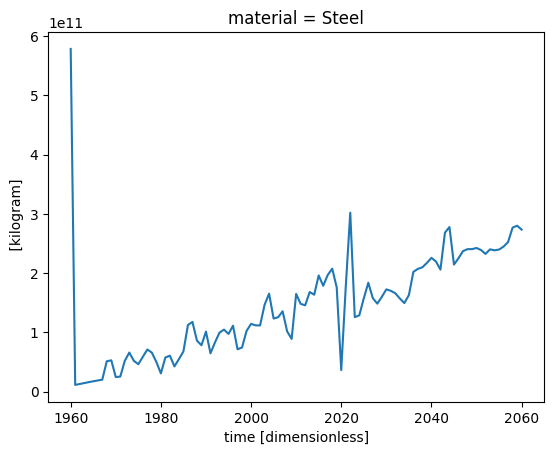

: 

: 

: 

: 

: 

In [ ]:
model.vehicles.get('inflow_materials').to_array().sum(dim =['Region', 'Type']).sel(material = 'Steel').plot()

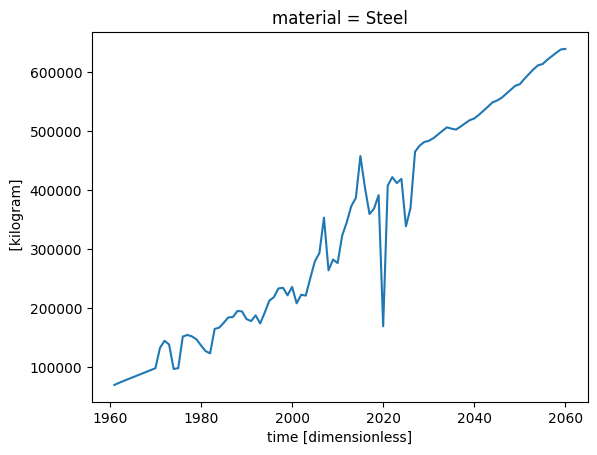

: 

: 

: 

: 

: 

In [ ]:
model.buildings.get('inflow_materials').to_array().sum(dim =['Region', 'Type']).sel(material = 'Steel').loc[1961:].plot()

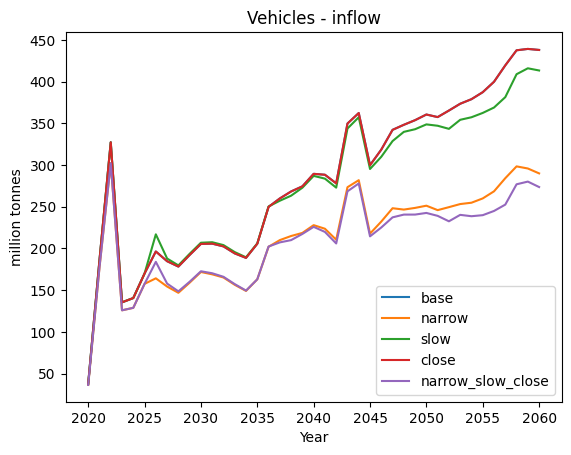

: 

: 

: 

: 

: 

: 

In [ ]:
from matplotlib import pyplot as plt
plt.title("Vehicles - inflow")
plt.xlabel("Year")
plt.ylabel("million tonnes")
for scen_id, output in all_output.items():
    inflow = output["inflow_materials"][0].to_array().sel(time=range(2020, 2061))
    time = inflow.coords["time"]
    plt.plot(time, inflow.sum("Region").sel(material="Steel").sum("Type")/1e9, label=scen_id)
plt.legend()
plt.show()

In [ ]:
from matplotlib import pyplot as plt
for scen_id, output in all_output.items():
    inflow = output["recyclable_materials"].to_array().sel(time=range(2020, 2061))
    time = inflow.coords["time"]
    plt.plot(time, inflow.sum("Region").sel(material="Steel").sum("Type"), label=scen_id)
plt.legend()
plt.show()

KeyError: 'recyclable_materials'

: 

: 

: 

: 

: 

: 

In [ ]:
from matplotlib import pyplot as plt
for scen_id, output in all_output.items():
    inflow = output["reusable_materials"].to_array().sel(time=range(2020, 2061))
    time = inflow.coords["time"]
    plt.plot(time, inflow.sum("Region").sel(material="Steel").sum("Type"), label=scen_id)
plt.legend()

KeyError: 'reusable_materials'

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

...

: 

: 

: 

: 

: 